In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
dataset_folder = 'data'

skin_images = os.path.join(dataset_folder, 'images')
skin_cropped_images = os.path.join(dataset_folder, 'skin_cropped')
ground_truth_images = os.path.join(dataset_folder, 'ground_truth')

In [6]:
image_files = sorted([f for f in os.listdir(skin_images) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
cropped_files = sorted([f for f in os.listdir(skin_cropped_images)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print("Full images:", len(image_files))
print("Cropped skin:", len(cropped_files))

Full images: 32
Cropped skin: 32


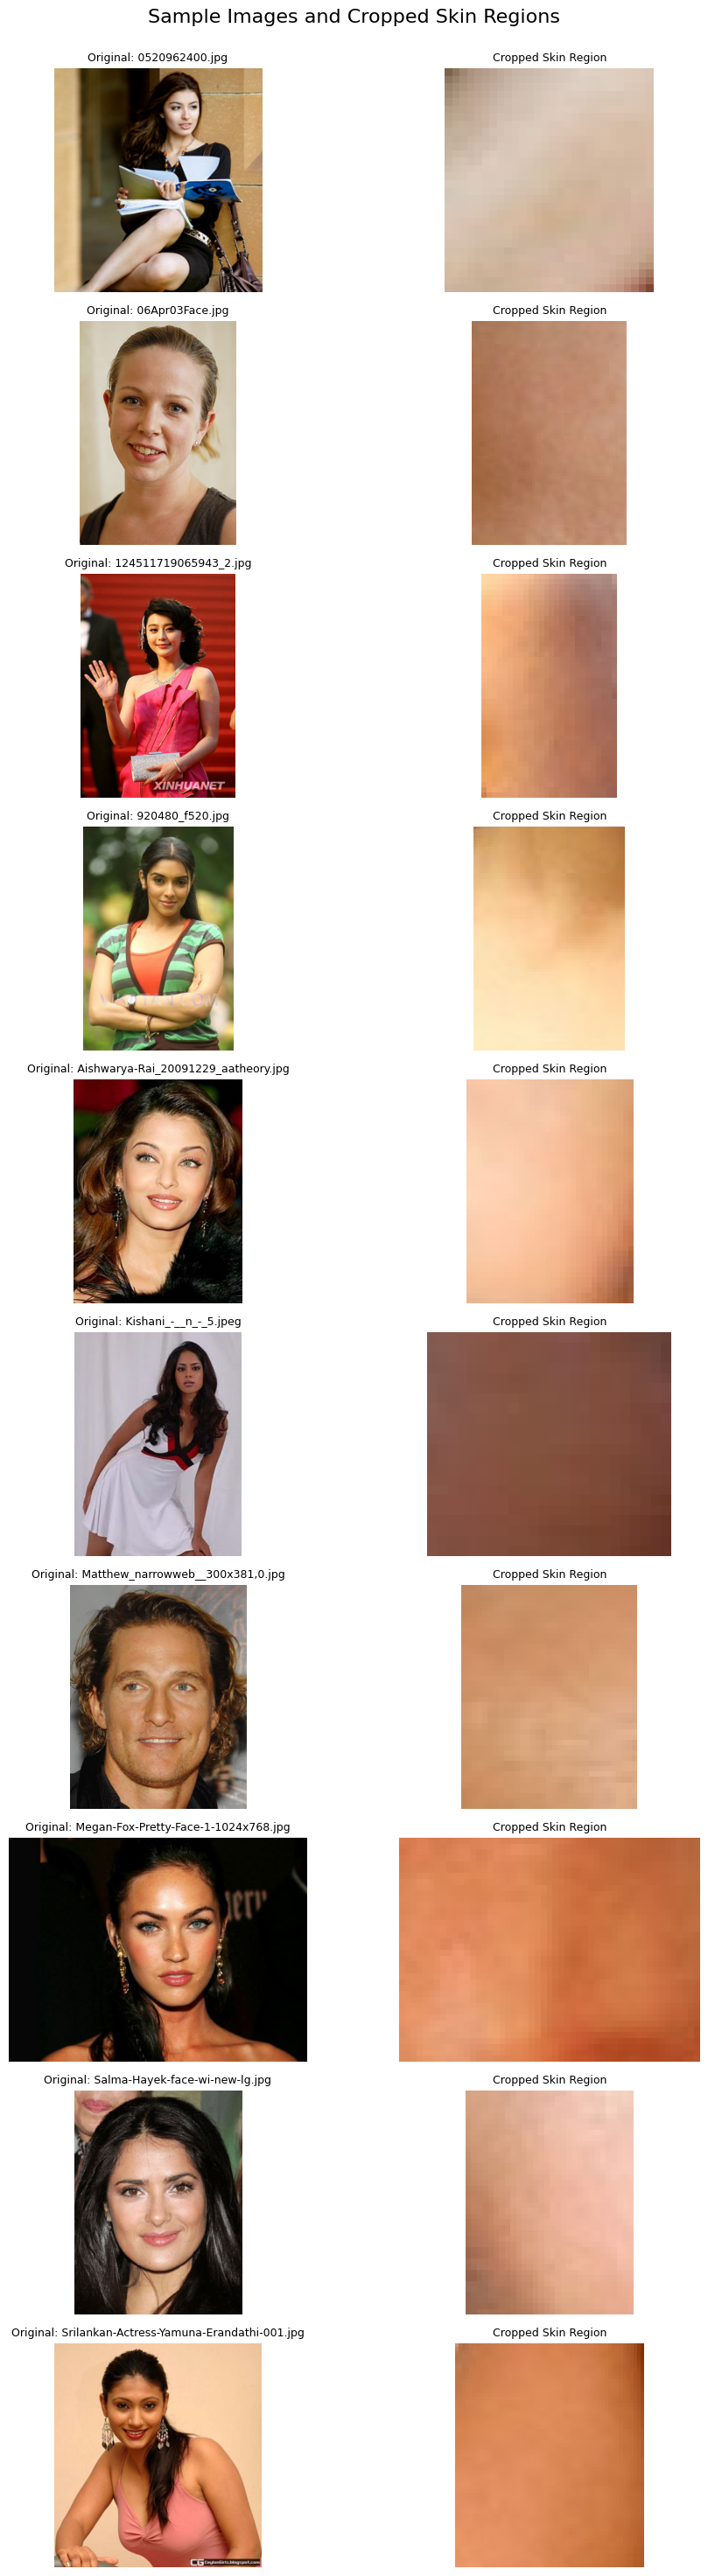

<Figure size 640x480 with 0 Axes>

In [11]:
sampleImg = image_files[:10]
fig, axes = plt.subplots(10, 2, figsize=(10, 30))
fig.suptitle('Sample Images and Cropped Skin Regions', fontsize=16)

def load_image(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for i, filename in enumerate(sampleImg):
    
    originalImgPath = os.path.join(skin_images, filename)
    originalImg = load_image(originalImgPath)

    fileName = os.path.splitext(filename)[0]

    for ext in ['.jpg', '.jpeg', '.png']:
        croppedImgPath = os.path.join(skin_cropped_images, fileName + ext)
        if os.path.exists(croppedImgPath):
            croppedImg = load_image(croppedImgPath)
            break

    axes[i, 0].imshow(originalImg)
    axes[i, 0].set_title(f'Original: {filename}', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(croppedImg)
    axes[i, 1].set_title('Cropped Skin Region', fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
plt.savefig('out/sample_images_cropped_and_original.png')
